In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import folium
from folium.plugins import MarkerCluster
import time
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [3]:
df = pd.read_csv("/content/Real Estate Data V21.csv")

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of Rows : 14528
Number of Columns : 9

Columns:
['Name', 'Property Title', 'Price', 'Location', 'Total_Area', 'Price_per_SQFT', 'Description', 'Baths', 'Balcony']


In [4]:
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            14528 non-null  object 
 1   Property Title  14528 non-null  object 
 2   Price           14528 non-null  object 
 3   Location        14528 non-null  object 
 4   Total_Area      14528 non-null  int64  
 5   Price_per_SQFT  14528 non-null  float64
 6   Description     14528 non-null  object 
 7   Baths           14528 non-null  int64  
 8   Balcony         14528 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1021.6+ KB


In [6]:
df = df.drop_duplicates()

df["Total_Area"] = pd.to_numeric(
    df["Total_Area"],
    errors="coerce"
)

df["Price_per_SQFT"] = pd.to_numeric(
    df["Price_per_SQFT"],
    errors="coerce"
)

In [8]:
import re
def convert_price(price):

    if pd.isna(price):
        return np.nan

    price = str(price)
    price = price.replace("₹", "")
    price = price.replace(",", "")
    price = price.strip()

    if "Cr" in price or "cr" in price:
        number = re.findall(r"[\d.]+", price)

        if len(number) > 0:
            return float(number[0]) * 10000000

    elif (
        "L" in price
        or "l" in price
        or "Lac" in price
        or "lac" in price
    ):
        number = re.findall(r"[\d.]+", price)

        if len(number) > 0:
            return float(number[0]) * 100000

    else:
        number = re.findall(r"[\d.]+", price)

        if len(number) > 0:
            return float(number[0])

    return np.nan

df["Price_Numeric"] = df["Price"].apply(convert_price)

df = df.dropna(subset=["Price_Numeric","Total_Area","Price_per_SQFT"])

df = df[(df["Price_Numeric"] > 0) & (df["Total_Area"] > 0) & (df["Price_per_SQFT"] > 0)]

print("\nCleaned Dataset Shape:")
print(df.shape)

print("\nCleaned Data:")
print(df[["Name","Location","Price","Price_Numeric","Total_Area","Price_per_SQFT"]].head())


Cleaned Dataset Shape:
(14517, 10)

Cleaned Data:
                                      Name  \
0                         Casagrand ECR 14   
1    Ramanathan Nagar, Pozhichalur,Chennai   
2                              DAC Prapthi   
3  Naveenilaya,Chepauk, Triplicane,Chennai   
4                 VGN Spring Field Phase 1   

                                   Location     Price  Price_Numeric  \
0             Kanathur Reddikuppam, Chennai  ₹1.99 Cr     19900000.0   
1     Ramanathan Nagar, Pozhichalur,Chennai  ₹2.25 Cr     22500000.0   
2  Kasthuribai Nagar, West Tambaram,Chennai   ₹1.0 Cr     10000000.0   
3   Naveenilaya,Chepauk, Triplicane,Chennai  ₹3.33 Cr     33300000.0   
4                            Avadi, Chennai   ₹48.0 L      4800000.0   

   Total_Area  Price_per_SQFT  
0        2583          7700.0  
1        7000          3210.0  
2        1320          7580.0  
3        4250          7840.0  
4         960          5000.0  


In [9]:
df["Calculated_Price_Per_SQFT"] = (
    df["Price_Numeric"] / df["Total_Area"]
)

df["Price_SQFT_Difference"] = (
    df["Price_per_SQFT"] -
    df["Calculated_Price_Per_SQFT"]
)

df["Price_Area_Ratio"] = (
    df["Price_Numeric"] /
    df["Total_Area"]
)

print(df[["Location","Price_Numeric","Total_Area","Price_Area_Ratio"]].head())

                                   Location  Price_Numeric  Total_Area  \
0             Kanathur Reddikuppam, Chennai     19900000.0        2583   
1     Ramanathan Nagar, Pozhichalur,Chennai     22500000.0        7000   
2  Kasthuribai Nagar, West Tambaram,Chennai     10000000.0        1320   
3   Naveenilaya,Chepauk, Triplicane,Chennai     33300000.0        4250   
4                            Avadi, Chennai      4800000.0         960   

   Price_Area_Ratio  
0       7704.219899  
1       3214.285714  
2       7575.757576  
3       7835.294118  
4       5000.000000  


In [10]:
q1 = df["Price_Area_Ratio"].quantile(0.33)
q2 = df["Price_Area_Ratio"].quantile(0.66)

def assign_category(value):

    if value <= q1:
        return "Affordable"

    elif value <= q2:
        return "Casual"

    else:
        return "Premium"

df["Price_Area_Comparison"] = (
    df["Price_Area_Ratio"].apply(assign_category)
)

print("\nCategory Distribution:")
print(df["Price_Area_Comparison"].value_counts())


Category Distribution:
Price_Area_Comparison
Premium       4936
Affordable    4792
Casual        4789
Name: count, dtype: int64


In [11]:
X = df[["Price_Numeric","Total_Area"]].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

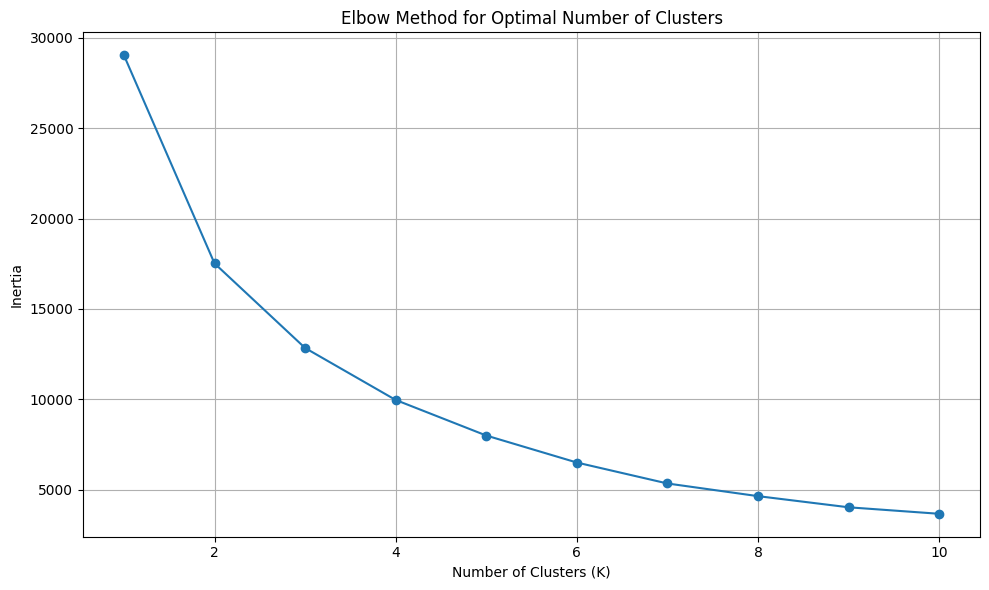

In [12]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig("elbow_method.png",dpi=300)

plt.show()

In [13]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

print("\nCluster Counts:")
print(df["Cluster"].value_counts())


Cluster Counts:
Cluster
0    13234
1     1236
2       47
Name: count, dtype: int64


In [14]:
cluster_summary = df.groupby(
    "Cluster"
).agg(
    Average_Price=(
        "Price_Numeric",
        "mean"
    ),
    Average_Area=(
        "Total_Area",
        "mean"
    ),
    Average_Price_Per_SQFT=(
        "Price_Area_Ratio",
        "mean"
    )
).reset_index()


print("\nCluster Summary:")
print(cluster_summary)

sorted_clusters = (
    cluster_summary
    .sort_values(
        "Average_Price_Per_SQFT"
    )
    ["Cluster"]
    .tolist()
)

cluster_category_mapping = {

    sorted_clusters[0]: "Affordable",

    sorted_clusters[1]: "Casual",

    sorted_clusters[2]: "Premium"
}

df["ML_Category"] = df[
    "Cluster"
].map(
    cluster_category_mapping
)


print("\nFinal Category Counts:")

print(df["ML_Category"].value_counts())


Cluster Summary:
   Cluster  Average_Price  Average_Area  Average_Price_Per_SQFT
0        0   7.601825e+06   1022.832175             7947.366929
1        1   3.534407e+07   4087.860841            11293.375954
2        2   2.278191e+08   5326.042553           106362.273093

Final Category Counts:
ML_Category
Affordable    13234
Casual         1236
Premium          47
Name: count, dtype: int64


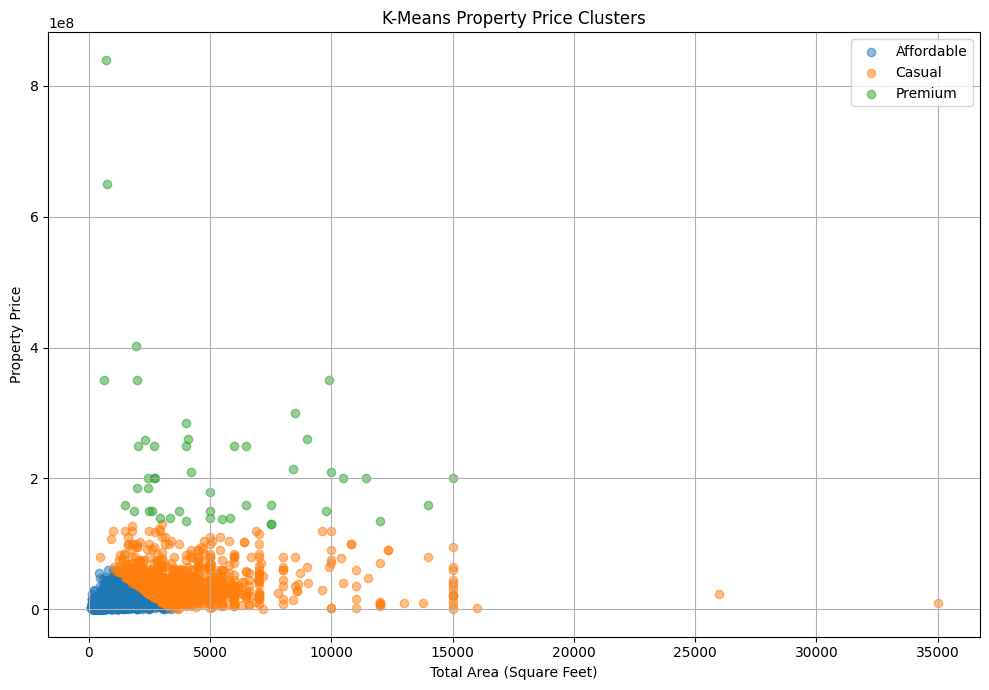

In [15]:
plt.figure(figsize=(10, 7))

for category in ["Affordable","Casual","Premium"]:

    subset = df[
        df["ML_Category"] == category
    ]

    plt.scatter(
        subset["Total_Area"],
        subset["Price_Numeric"],
        label=category,
        alpha=0.5
    )

plt.xlabel("Total Area (Square Feet)")
plt.ylabel("Property Price")
plt.title("K-Means Property Price Clusters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("kmeans_clusters.png",dpi=300)
plt.show()

In [16]:
unique_locations = (
    df["Location"]
    .dropna()
    .unique()
)

print(
    "Number of Unique Locations:",
    len(unique_locations)
)

Number of Unique Locations: 7049


In [18]:
geolocator = Nominatim(
    user_agent="property_price_ml_project"
)

geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1
)

location_coordinates = {}
unique_locations = (df["Location"]
    .dropna()
    .unique()
)

for location in unique_locations:

    try:

        search_location = (
            str(location) +
            ", Tamil Nadu, India"
        )

        result = geocode(
            search_location
        )

        if result:
          location_coordinates[location] = (result.latitude,result.longitude)

    except Exception:pass

In [19]:
df["Latitude"] = df["Location"].map(
    lambda x:
    location_coordinates.get(x,(None, None))[0]
)


df["Longitude"] = df["Location"].map(
    lambda x:
    location_coordinates.get(x,(None, None))[1]
)

map_df = df.dropna(
    subset=["Latitude","Longitude"]
).copy()


In [20]:
map_center = [13.0827,80.2707]

property_map = folium.Map(
    location=map_center,
    zoom_start=10,
    tiles="OpenStreetMap"
)

marker_cluster = MarkerCluster().add_to(property_map)

In [28]:
marker_cluster = MarkerCluster().add_to(
    property_map
)

for index, row in map_df.iterrows():

    popup_html = f"""
    <div style="width:300px">

        <b>Location:</b>
        {row['Location']}

        <br><br>

        <b>Price:</b>
        ₹{row['Price_Numeric']:,.0f}

        <br><br>

        <b>Category:</b>
        {row['ML_Category']}

        <br><br>

    </div>
    """

    folium.Marker(

        location=[
            row["Latitude"],
            row["Longitude"]
        ],

        popup=folium.Popup(
            popup_html,
            max_width=350
        ),

        tooltip=(
            f"{row['Location']} | "
            f"₹{row['Price_Numeric']:,.0f} | "
            f"{row['Total_Area']:,.0f} sq.ft | "
            f"{row['ML_Category']}"
        )

    ).add_to(
        marker_cluster
    )

display(property_map)

In [29]:
property_map.save(
    "property_price_interactive_map.html"
)